The Random Forest Regression model was chosen for this project because of its robustness in handling high-dimensional, non-linear data with many features, including one-hot encoded categorical variables such as U.S. states and industrial sectors. The dataset included over 200 features derived from greenhouse gas (GHG) emission amounts by gas type, sector, and state over time.

Mean Absolute Error (MAE): 259,909,196.91
Root Mean Squared Error (RMSE): 5,649,172,077.12
R² Score: 0.9993


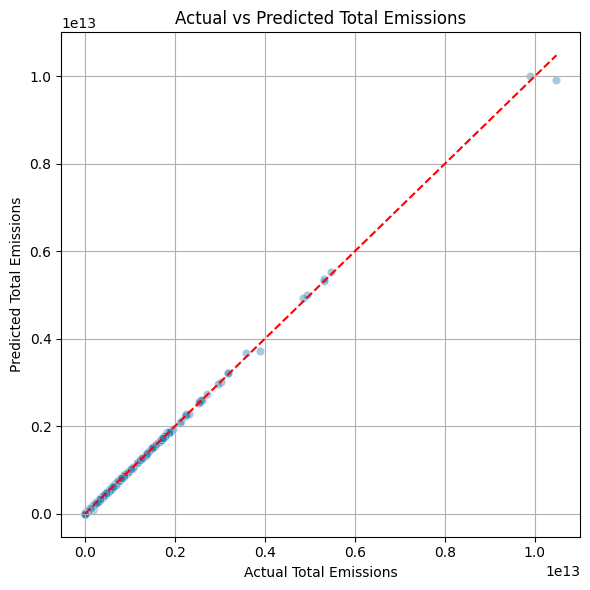

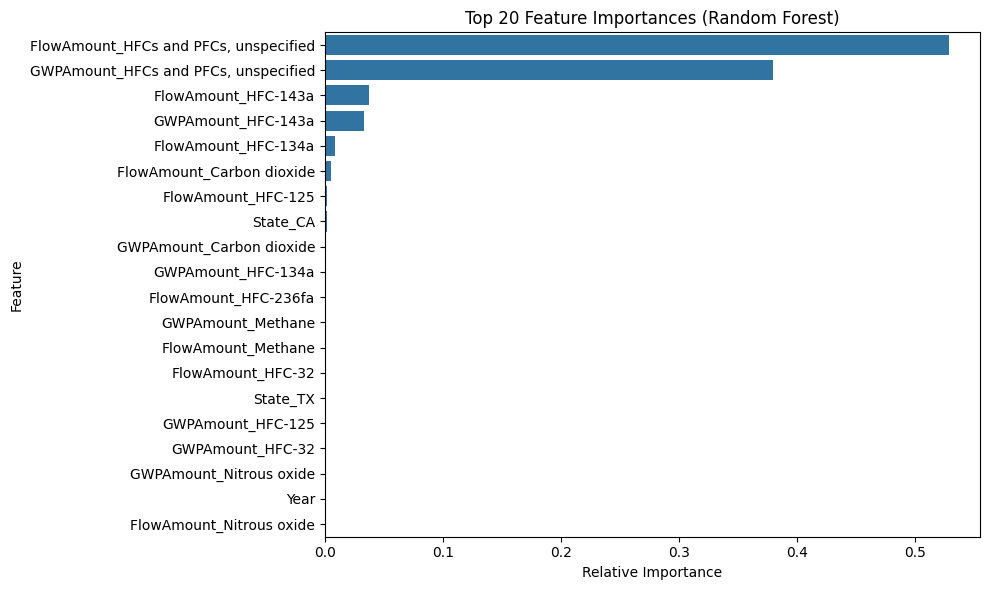

In [1]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

df = pd.read_csv("ghg_preprocessed.csv")

#Define the features and target
X = df.drop(columns=["TotalEmissions"])
y = df["TotalEmissions"]

#Train-Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Train Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

#Predict on test set
y_pred = rf_model.predict(X_test)

#Evaluate model performance
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")
print(f"R² Score: {r2:.4f}")

#Actual vs predicted plot
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.4)
plt.xlabel("Actual Total Emissions")
plt.ylabel("Predicted Total Emissions")
plt.title("Actual vs Predicted Total Emissions")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.tight_layout()
plt.grid(True)
plt.show()

#Calculate feature importance
importances = rf_model.feature_importances_
feature_names = X.columns
importance_df = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importance_df[:20], y=importance_df[:20].index)
plt.title("Top 20 Feature Importances (Random Forest)")
plt.xlabel("Relative Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

The model achieved a very high R² score of 0.9993, indicating that it explains over 99.9% of the variance in total CO₂-equivalent emissions. The Mean Absolute Error (MAE) of ~260 million kg CO₂e and the Root Mean Squared Error (RMSE) of around 5.6 billion kg CO₂e further affirm the model’s strong predictive performance—especially when placed in context: the target variable (TotalEmissions) often ranges in the tens of billions of kilograms. These results demonstrate that total emissions can be reliably and accurately predicted using the detailed breakdowns of greenhouse gas types (FlowAmount, GWPAmount), sector activity, and state-level identifiers.

The Random Forest model identified that unspecified HFCs and PFCs are the most critical drivers of total CO₂-equivalent emissions, dominating the top feature importances. Specific gases like HFC-143a, Carbon Dioxide, Methane, and Nitrous Oxide also contribute meaningfully. Additionally, state-level indicators such as State_CA and State_TX appeared among the top 20 features, highlighting geographic patterns in emissions. The Year feature had very low importance, confirming that emissions are more influenced by what and where emissions occur rather than by when.